# Método de Lattice-Boltzmann

* PET - Física UFRN
* Petianos: Wallysson Pereira da Silva
* Data: 13/09/2026

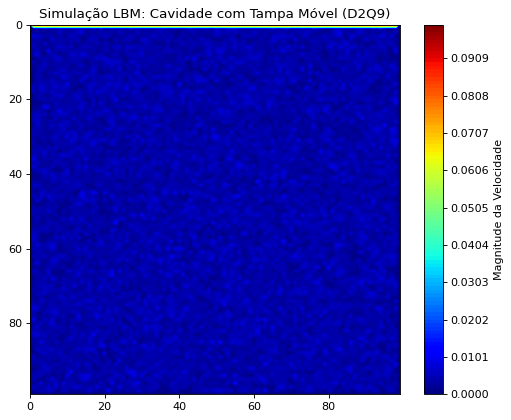

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Parâmetros de Simulação
Nx, Ny = 100, 100        # Resolução da grade
tau = 0.6                # Tempo de relaxação (relacionado à viscosidade)
Nt = 500                # Número de iterações
u_lid = 0.1              # Velocidade da tampa superior

# Pesos e direções do modelo D2Q9
NL = 9
idxs = np.arange(NL)
cxs = np.array([0, 0, 1, 0, -1, 1, -1, -1, 1])
cys = np.array([0, 1, 0, -1, 0, 1, 1, -1, -1])
weights = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36]) # Pesos de Lattice

# Inicialização
F = np.ones((Ny, Nx, NL)) # Função de distribuição de partículas
np.random.seed(42)
F += 0.01 * np.random.randn(Ny, Nx, NL) # Pequena perturbação inicial
X, Y = np.meshgrid(range(Nx), range(Ny))

# Máscaras de Contorno (Paredes)
cylinder = np.full((Ny, Nx), False)

u_x_values = []
u_y_values = []

# Loop Principal
for it in range(Nt):
    # 1. Variáveis Macroscópicas
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs, axis=2) / rho
    uy = np.sum(F * cys, axis=2) / rho

    # Condições de Contorno Macroscópicas (Tampa móvel)
    ux[0, :] = u_lid  # Parede superior movendo-se para a direita
    uy[0, :] = 0
    ux[:, 0] = 0; uy[:, 0] = 0   # Parede esquerda
    ux[:, -1] = 0; uy[:, -1] = 0 # Parede direita
    ux[-1, :] = 0; uy[-1, :] = 0 # Parede inferior
    
    # 2. Colisão (Equilíbrio e Relaxação BGK)
    Feq = np.zeros((Ny, Nx, NL))
    for i, cx, cy, w in zip(idxs, cxs, cys, weights):
        cu = 3 * (cx * ux + cy * uy)
        Feq[:, :, i] = rho * w * (1 + cu + 0.5 * cu**2 - 1.5 * (ux**2 + uy**2))
    
    F += -(1.0 / tau) * (F - Feq)
    
    # 3. Condição de Contorno Microcópica (Bounce-Back nas paredes estacionárias)
    for i, cx, cy in zip(idxs, cxs, cys):
        # Parede direita e esquerda
        F[:, 0, i] = Feq[:, 0, i]
        F[:, -1, i] = Feq[:, -1, i]
        # Parede inferior
        F[-1, :, i] = Feq[-1, :, i]
        # A parede superior já foi forçada pelas variáveis macroscópicas + Feq
        F[0, :, i] = Feq[0, :, i]

    # 4. Propagação (Streaming)
    for i, cx, cy in zip(idxs, cxs, cys):
        F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)

    u_x_values.append(ux)
    u_y_values.append(uy)    


# --- INÍCIO DA VISUALIZAÇÃO CORRIGIDA ---

# Fixando os níveis de cor de 0 até a velocidade da tampa para a escala não piscar
levels = np.linspace(0, u_lid, 100)

velocity = np.sqrt(u_x_values[0]**2 + u_y_values[0]**2)
fig, ax = plt.subplots(figsize=(8, 6), dpi=80)

# Plota o frame inicial usando os níveis fixos
contour = ax.contourf(X, Y, velocity, levels=levels, cmap='jet')
fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')
ax.set_title('Simulação LBM: Cavidade com Tampa Móvel (D2Q9)')
ax.set_aspect('equal')

# Inverte o eixo Y para a linha 0 (tampa) ficar no topo!
ax.invert_yaxis()

def atualizar(frame):
    global contour
    # Remove apenas as cores antigas, mantendo os eixos e o colorbar intactos
    for c in contour.collections:
        c.remove()
    
    ax.set_title(f"Simulação LBM: Cavidade com Tampa Móvel (D2Q9) - {frame/Nt*100:.0f}%") 

    # Calcula a velocidade do frame atual
    vel_atual = np.sqrt(u_x_values[frame]**2 + u_y_values[frame]**2)
    
    # Plota o novo contorno com os MESMOS níveis de cor
    contour = ax.contourf(X, Y, vel_atual, levels=levels, cmap='jet')
    
    # Print de progresso mais limpo (a cada 50 frames)
    if frame % 50 == 0:
        print(f"Renderizando frame {frame}/{Nt}...")
    
    return contour.collections



In [38]:
# blit=False é muito mais estável para salvar GIFs com contourf
anim = FuncAnimation(fig, atualizar, frames=Nt, interval=60, blit=False)
plt.close(fig) 

caminho = '../Imagens/Boltzmann/Tampa_Movel.gif' # Ajuste para o seu diretório: '../Imagens/Boltzmann/Tampa_Movel.gif'
anim.save(caminho, writer='pillow')
print("GIF salvo com sucesso!")

C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\133884736.py:91: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in contour.collections:
C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\133884736.py:106: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return contour.collections


Renderizando frame 0/500...
Renderizando frame 0/500...
Renderizando frame 50/500...
Renderizando frame 100/500...
Renderizando frame 150/500...
Renderizando frame 200/500...
Renderizando frame 250/500...
Renderizando frame 300/500...
Renderizando frame 350/500...
Renderizando frame 400/500...
Renderizando frame 450/500...
GIF salvo com sucesso!


# Corrigido?

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Parâmetros de Simulação
Nx, Ny = 100, 100        # Resolução da grade
tau = 0.6                # Tempo de relaxação (relacionado à viscosidade)
Nt = 1500                 # Número de iterações
u_lid = 0.1              # Velocidade da tampa superior

# Pesos e direções do modelo D2Q9
NL = 9
idxs = np.arange(NL)
cxs = np.array([0, 0, 1, 0, -1, 1, -1, -1, 1])
cys = np.array([0, 1, 0, -1, 0, 1, 1, -1, -1])
weights = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36]) 
opostos = np.array([0, 3, 4, 1, 2, 7, 8, 5, 6]) # Índices das direções opostas (180°)

# Inicialização (Sem perturbação aleatória para evitar ondas de choque)
F = np.zeros((Ny, Nx, NL)) 
rho_inicial = 1.0
for i, w in zip(idxs, weights):
    F[:, :, i] = rho_inicial * w

X, Y = np.meshgrid(range(Nx), range(Ny))
u_x_values = []
u_y_values = []

# Loop Principal
for it in range(Nt):
    # 1. Variáveis Macroscópicas
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs, axis=2) / rho
    uy = np.sum(F * cys, axis=2) / rho

    # Condições de Contorno Macroscópicas
    ux[0, 1:-1] = u_lid  # Tampa superior
    uy[0, 1:-1] = 0
    ux[:, 0] = 0; uy[:, 0] = 0   # Esquerda
    ux[:, -1] = 0; uy[-1, :] = 0 # Direita e Inferior
    
    # 2. Equilíbrio e Colisão BGK
    Feq = np.zeros((Ny, Nx, NL))
    for i, cx, cy, w in zip(idxs, cxs, cys, weights):
        cu = 3 * (cx * ux + cy * uy)
        Feq[:, :, i] = rho * w * (1 + cu + 0.5 * cu**2 - 1.5 * (ux**2 + uy**2))
    
    F_post = F - (1.0 / tau) * (F - Feq)
    
    # 3. Propagação (Streaming)
    for i, cx, cy in zip(idxs, cxs, cys):
        F[:, :, i] = np.roll(F_post[:, :, i], cx, axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)

    # 4. Condição de Contorno Microcópica (Bounce-Back)
    for i in idxs:
        F[:, 0, i] = F_post[:, 0, opostos[i]]   # Parede esquerda
        F[:, -1, i] = F_post[:, -1, opostos[i]] # Parede direita
        F[-1, :, i] = F_post[-1, :, opostos[i]] # Parede inferior
        F[0, :, i] = Feq[0, :, i]               # Tampa superior (Dirichlet)

    u_x_values.append(ux)
    u_y_values.append(uy)    

# --- VISUALIZAÇÃO E ANIMAÇÃO ---

levels = np.linspace(0, u_lid, 100) # Fixa a escala de cores
velocity = np.sqrt(u_x_values[0]**2 + u_y_values[0]**2)

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
contour = ax.contourf(X, Y, velocity, levels=levels, cmap='jet')
fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')

ax.set_title('Simulação LBM: Cavidade com Tampa Móvel (D2Q9)')
ax.set_aspect('equal')
ax.invert_yaxis() # Tampa na parte superior visualmente

def atualizar(frame):
    global contour
    for c in contour.collections:
        c.remove()

    ax.set_title(f'Simulação LBM: Cavidade com Tampa Móvel (D2Q9) {frame/Nt*100:.0f}%')
    vel_atual = np.sqrt(u_x_values[frame]**2 + u_y_values[frame]**2)
    contour = ax.contourf(X, Y, vel_atual, levels=levels, cmap='jet')
    
    if frame % 50 == 0:
        print(f"Renderizando frame {frame}/{Nt}...")
    
    return contour.collections

anim = FuncAnimation(fig, atualizar, frames=Nt, interval=60, blit=False)
plt.close(fig) 

caminho = '../Imagens/Boltzmann/Tampa_Movel_teste.gif' # Ajuste para o seu diretório: '../Imagens/Boltzmann/Tampa_Movel.gif'
anim.save(caminho, writer='pillow')
print("GIF salvo com sucesso!")

C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\2008549101.py:80: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in contour.collections:
C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\2008549101.py:90: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return contour.collections


Renderizando frame 0/500...
Renderizando frame 0/500...
Renderizando frame 50/500...
Renderizando frame 100/500...
Renderizando frame 150/500...
Renderizando frame 200/500...
Renderizando frame 250/500...
Renderizando frame 300/500...
Renderizando frame 350/500...
Renderizando frame 400/500...
Renderizando frame 450/500...
GIF salvo com sucesso!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros da Simulação
Nx, Ny = 400, 100        # Grade retangular (canal)
tau = 0.53               # Viscosidade baixa para permitir turbulência
Nt = 2000                # Número de passos de tempo
u_in = 0.04              # Velocidade de entrada do fluido

# Pesos e direções do modelo D2Q9
NL = 9
cxs = np.array([0, 0, 1, 0, -1, 1, -1, -1, 1])
cys = np.array([0, 1, 0, -1, 0, 1, 1, -1, -1])
weights = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])

# Definindo o Obstáculo (Cilindro)
X, Y = np.meshgrid(range(Nx), range(Ny))
cylinder = (X - Nx//4)**2 + (Y - Ny//2)**2 < (Ny//6)**2

# Inicialização
rho = np.ones((Ny, Nx))
ux = np.full((Ny, Nx), u_in)
uy = np.zeros((Ny, Nx))
F = np.zeros((Ny, Nx, NL))

# Função de Equilíbrio (usada na inicialização e na colisão)
def equilibrium(rho, ux, uy):
    Feq = np.zeros((Ny, Nx, NL))
    u_sq = ux**2 + uy**2
    for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
        cu = cx * ux + cy * uy
        Feq[:, :, i] = rho * w * (1 + 3*cu + 4.5*cu**2 - 1.5*u_sq)
    return Feq

F = equilibrium(rho, ux, uy)

u_x_values = []
u_y_values = []

# Loop Principal LBM
for it in range(Nt):
    # Condição de Contorno: Entrada de fluxo constante à esquerda
    for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
        if cx > 0:
            F[:, 0, i] = w * (1 + 3*u_in + 4.5*u_in**2 - 1.5*u_in**2)

    # Propagação (Streaming)
    for i, cx, cy in zip(range(NL), cxs, cys):
        F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)
        
    # Bounce-back no cilindro
    bndryF = F[cylinder, :]
    bndryF = bndryF[:, [0, 3, 4, 1, 2, 7, 8, 5, 6]] # Inverte as direções
    
    # Variáveis Macroscópicas
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs, axis=2) / rho
    uy = np.sum(F * cys, axis=2) / rho
    
    # Aplica velocidade zero dentro do obstáculo
    ux[cylinder] = 0
    uy[cylinder] = 0
    rho[cylinder] = 1
    
    # Colisão BGK
    Feq = equilibrium(rho, ux, uy)
    F += -(1.0 / tau) * (F - Feq)
    
    # Reaplica as partículas refletidas pelo obstáculo
    F[cylinder, :] = bndryF

    u_x_values.append(ux)
    u_y_values.append(uy)    
    

# Visualização do campo de velocidade (Vorticidade ou Magnitude)
velocity = np.sqrt(ux**2 + uy**2)
velocity[cylinder] = 0

plt.figure(figsize=(12, 4))
plt.contourf(X, Y, velocity, 100, cmap='inferno')
plt.colorbar(label='Magnitude da Velocidade')
# Desenhando o contorno do cilindro
plt.contour(X, Y, cylinder, levels=[0.5], colors='cyan', linewidths=2)
plt.title(f'Fluxo ao redor de um cilindro após {Nt} iterações')
plt.gca().set_aspect('equal')
plt.show()

Salvando o GIF (isso pode levar alguns minutos dependendo da sua máquina)...
Renderizando frame 0/2000...
Renderizando frame 0/2000...


C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\4159171685.py:108: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in contour.collections:
C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\4159171685.py:122: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return contour.collections


Renderizando frame 200/2000...
Renderizando frame 400/2000...
Renderizando frame 600/2000...
Renderizando frame 800/2000...
Renderizando frame 1000/2000...
Renderizando frame 1200/2000...
Renderizando frame 1400/2000...
Renderizando frame 1600/2000...
Renderizando frame 1800/2000...
GIF salvo com sucesso!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros da Simulação
Nx, Ny = 400, 100        # Grade retangular (canal)
tau = 0.53               # Viscosidade baixa para permitir turbulência
Nt = 2000                # Número de passos de tempo
u_in = 0.04              # Velocidade de entrada do fluido

# Pesos e direções do modelo D2Q9
NL = 9
cxs = np.array([0, 0, 1, 0, -1, 1, -1, -1, 1])
cys = np.array([0, 1, 0, -1, 0, 1, 1, -1, -1])
weights = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])

# Definindo o Obstáculo (Cilindro)
X, Y = np.meshgrid(range(Nx), range(Ny))
cylinder = (X - Nx//4)**2 + (Y - Ny//2)**2 < (Ny//6)**2

# Inicialização
rho = np.ones((Ny, Nx))
ux = np.full((Ny, Nx), u_in)
uy = np.zeros((Ny, Nx))
F = np.zeros((Ny, Nx, NL))

# Função de Equilíbrio (usada na inicialização e na colisão)
def equilibrium(rho, ux, uy):
    Feq = np.zeros((Ny, Nx, NL))
    u_sq = ux**2 + uy**2
    for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
        cu = cx * ux + cy * uy
        Feq[:, :, i] = rho * w * (1 + 3*cu + 4.5*cu**2 - 1.5*u_sq)
    return Feq

F = equilibrium(rho, ux, uy)

u_x_values = []
u_y_values = []

# Loop Principal LBM
for it in range(Nt):
    # Condição de Contorno: Entrada de fluxo constante à esquerda
    for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
        if cx > 0:
            F[:, 0, i] = w * (1 + 3*u_in + 4.5*u_in**2 - 1.5*u_in**2)

    # Propagação (Streaming)
    for i, cx, cy in zip(range(NL), cxs, cys):
        F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)
        
    # Bounce-back no cilindro
    bndryF = F[cylinder, :]
    bndryF = bndryF[:, [0, 3, 4, 1, 2, 7, 8, 5, 6]] # Inverte as direções
    
    # Variáveis Macroscópicas
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs, axis=2) / rho
    uy = np.sum(F * cys, axis=2) / rho
    
    # Aplica velocidade zero dentro do obstáculo
    ux[cylinder] = 0
    uy[cylinder] = 0
    rho[cylinder] = 1
    
    # Colisão BGK
    Feq = equilibrium(rho, ux, uy)
    F += -(1.0 / tau) * (F - Feq)
    
    # Reaplica as partículas refletidas pelo obstáculo
    F[cylinder, :] = bndryF

    u_x_values.append(ux)
    u_y_values.append(uy)    
    

# --- INÍCIO DA VISUALIZAÇÃO E ANIMAÇÃO ---

# É recomendado não animar TODOS os 2000 frames. 
# Vamos pular de 10 em 10 frames para o GIF renderizar rápido e não ficar pesado.
passo_animacao = 10
frames_animacao = range(0, Nt, passo_animacao)

# Definimos uma velocidade máxima para travar as cores.
# No escoamento ao redor de um cilindro, a velocidade máxima passa um pouco de u_in.
v_max = u_in * 1.5 
levels = np.linspace(0, v_max, 80)

fig, ax = plt.subplots(figsize=(12, 4), dpi=80)

# Calcula o primeiro frame
velocity = np.sqrt(u_x_values[0]**2 + u_y_values[0]**2)
velocity[cylinder] = 0

# Plota o fundo inicial (extend='max' garante que velocidades acima de v_max não fiquem brancas)
contour = ax.contourf(X, Y, velocity, levels=levels, cmap='inferno', extend='max')
fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')

# Desenha o cilindro (isso fica estático, então fazemos apenas uma vez fora da função)
ax.contour(X, Y, cylinder, levels=[0.5], colors='cyan', linewidths=2)

ax.set_title('Fluxo ao redor de um cilindro (Esteira de von Kármán)')
ax.set_aspect('equal')

def atualizar(frame):
    global contour
    # Remove o mapa de calor antigo
    for c in contour.collections:
        c.remove()

    ax.set_title(f'Fluxo ao redor de um cilindro {frame/Nt*100:.0f}%')
    
    # Calcula a velocidade do frame atual
    vel_atual = np.sqrt(u_x_values[frame]**2 + u_y_values[frame]**2)
    vel_atual[cylinder] = 0
    
    # Plota a nova camada
    contour = ax.contourf(X, Y, vel_atual, levels=levels, cmap='inferno', extend='max')
    
    # Print para você saber que o Python não travou durante a renderização
    if frame % 200 == 0:
        print(f"Renderizando frame {frame}/{Nt}...")
        
    return contour.collections

# blit=False previne bugs gráficos ao atualizar o contourf
anim = FuncAnimation(fig, atualizar, frames=frames_animacao, interval=50, blit=False)
plt.close(fig) 

caminho = '../Imagens/Boltzmann/Cilindro.gif' 
print("Salvando o GIF (isso pode levar alguns minutos dependendo da sua máquina)...")
anim.save(caminho, writer='pillow')
print("GIF salvo com sucesso!")

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
C:\Users\noky2\AppData\Local\Temp\ipykernel_9820\612141652.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('x = E / (N$\epsilon$)')


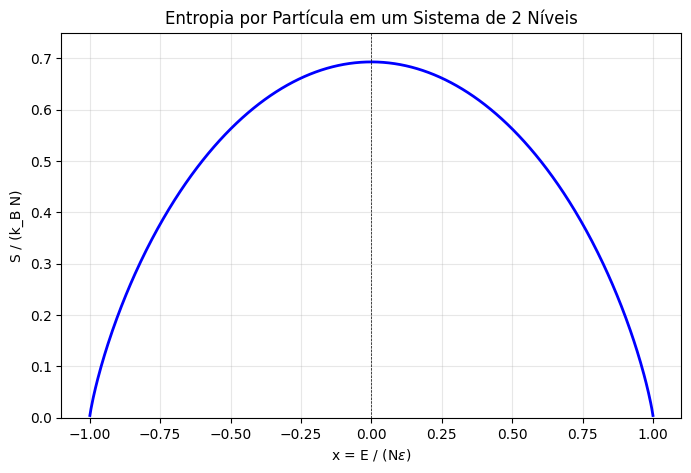

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir o domínio de x (evitando exatamente 1 e -1 para não dar erro no logaritmo de 0)
x = np.linspace(-0.999, 0.999, 500)

# Calcular y = S / (kb * N)
y = -((1 + x) / 2) * np.log((1 + x) / 2) - ((1 - x) / 2) * np.log((1 - x) / 2)

# Plotar
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', lw=2)
plt.title('Entropia por Partícula em um Sistema de 2 Níveis')
plt.xlabel('x = E / (N$\epsilon$)')
plt.ylabel('S / (k_B N)')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.axhline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(0, 0.75)
plt.show()

In [ ]:
levels = np.linspace(0, u_lid, 100) # Fixa a escala de cores
velocity = np.sqrt(u_x_values[0]**2 + u_y_values[0]**2)
velocity[cylinder] = 0


fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
contour = ax.contourf(X, Y, velocity, levels=levels, cmap='inferno')
# Desenhando o contorno do cilindro
plt.contour(X, Y, cylinder, levels=[0.5], colors='cyan', linewidths=2)
fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')
ax.set_title(f'Fluxo ao redor de um cilindro')
ax.set_aspect('equal')
# ax.invert_yaxis() # Tampa na parte superior visualmente

def atualizar(frame):
    global contour
    for c in contour.collections:
        c.remove()

    ax.set_title(f'Fluxo ao redor de um cilindro {frame/Nt*100:.0f}%')
    vel_atual = np.sqrt(u_x_values[frame]**2 + u_y_values[frame]**2)
    contour = ax.contourf(X, Y, vel_atual, levels=levels, cmap='inferno')
    # Desenhando o contorno do cilindro
    plt.contour(X, Y, cylinder, levels=[0.5], colors='cyan', linewidths=2)
    
    if frame % 50 == 0:
        print(f"Renderizando frame {frame}/{Nt}...")
    return contour.collections

anim = FuncAnimation(fig, atualizar, frames=Nt, interval=60, blit=False)


caminho = '../Imagens/Boltzmann/Cilindro.gif' 
anim.save(caminho, writer='pillow')
print("GIF salvo com sucesso!")
plt.close(fig) 

C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\3243309896.py:17: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in contour.collections:
C:\Users\noky2\AppData\Local\Temp\ipykernel_22380\3243309896.py:28: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return contour.collections


Renderizando frame 0/2000...
Renderizando frame 0/2000...
Renderizando frame 50/2000...
Renderizando frame 100/2000...
Renderizando frame 150/2000...
GIF salvo com sucesso!


In [ ]:
from matplotlib.animation import FuncAnimation

# --- INÍCIO DA VISUALIZAÇÃO E ANIMAÇÃO ---

# É recomendado não animar TODOS os 2000 frames. 
# Vamos pular de 10 em 10 frames para o GIF renderizar rápido e não ficar pesado.
passo_animacao = 10
frames_animacao = range(0, Nt, passo_animacao)

# Definimos uma velocidade máxima para travar as cores.
# No escoamento ao redor de um cilindro, a velocidade máxima passa um pouco de u_in.
v_max = u_in * 1.5 
levels = np.linspace(0, v_max, 80)

fig, ax = plt.subplots(figsize=(12, 4), dpi=80)

# Calcula o primeiro frame
velocity = np.sqrt(u_x_values[0]**2 + u_y_values[0]**2)
velocity[cylinder] = 0

# Plota o fundo inicial (extend='max' garante que velocidades acima de v_max não fiquem brancas)
contour = ax.contourf(X, Y, velocity, levels=levels, cmap='inferno', extend='max')
fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')

# Desenha o cilindro (isso fica estático, então fazemos apenas uma vez fora da função)
ax.contour(X, Y, cylinder, levels=[0.5], colors='cyan', linewidths=2)

ax.set_title('Fluxo ao redor de um cilindro (Esteira de von Kármán)')
ax.set_aspect('equal')

def atualizar(frame):
    global contour
    # Remove o mapa de calor antigo
    for c in contour.collections:
        c.remove()
    
    # Calcula a velocidade do frame atual
    vel_atual = np.sqrt(u_x_values[frame]**2 + u_y_values[frame]**2)
    vel_atual[cylinder] = 0
    
    # Plota a nova camada
    contour = ax.contourf(X, Y, vel_atual, levels=levels, cmap='inferno', extend='max')
    
    # Print para você saber que o Python não travou durante a renderização
    if frame % 200 == 0:
        print(f"Renderizando frame {frame}/{Nt}...")
        
    return contour.collections

# blit=False previne bugs gráficos ao atualizar o contourf
anim = FuncAnimation(fig, atualizar, frames=frames_animacao, interval=50, blit=False)
plt.close(fig) 

caminho = 'Cilindro_vonKarman.gif'
print("Salvando o GIF (isso pode levar alguns minutos dependendo da sua máquina)...")
anim.save(caminho, writer='pillow')
print("GIF salvo com sucesso!")